[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [27]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.9


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

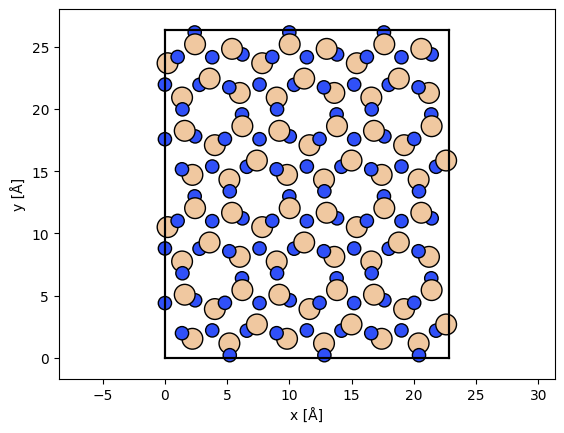

In [28]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.orthogonalize_cell(structure)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

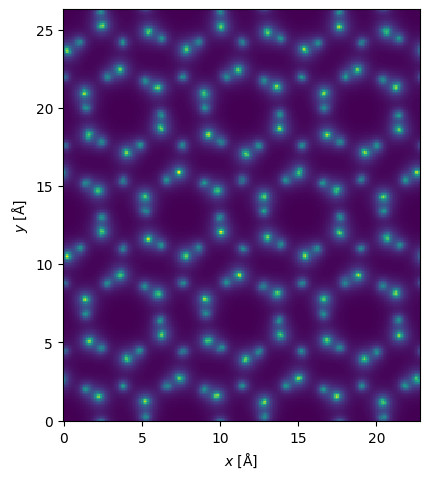

In [29]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

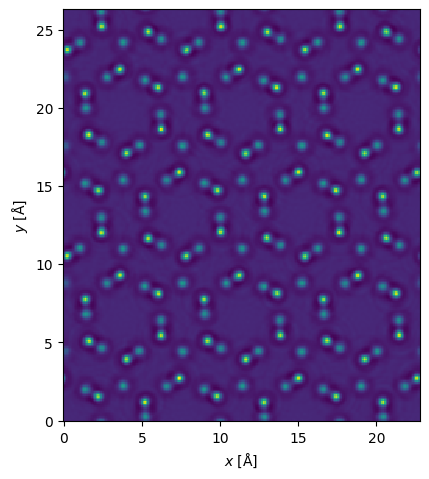

In [30]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
exit_waves.intensity().mean(0).show(cmap='viridis');


---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

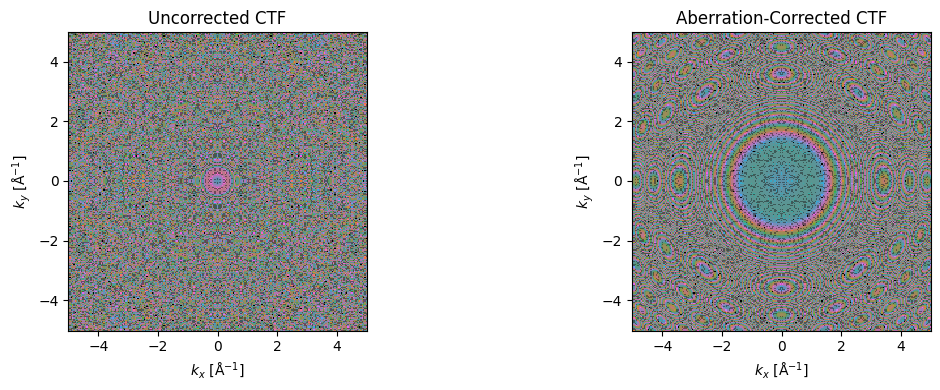

In [31]:
# TASK 3a: Define the UNCORRECTED CTF
ctf_uncorrected = abtem.CTF(energy=300e3, C10=-600, C30=1.3e7)

# TASK 3b: Define the ABERRATION-CORRECTED CTF
ctf_corrected = abtem.CTF(energy=300e3, C10=30, C30=-8e4)

# Match both CTFs to the exit-wave grid
ctf_uncorrected.match_grid(exit_waves)
ctf_corrected.match_grid(exit_waves)

# TASK 3c: Plot both CTFs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ctf_uncorrected.show(ax=axes[0])
axes[0].set_title("Uncorrected CTF")

ctf_corrected.show(ax=axes[1])
axes[1].set_title("Aberration-Corrected CTF")

plt.tight_layout()
plt.show()

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

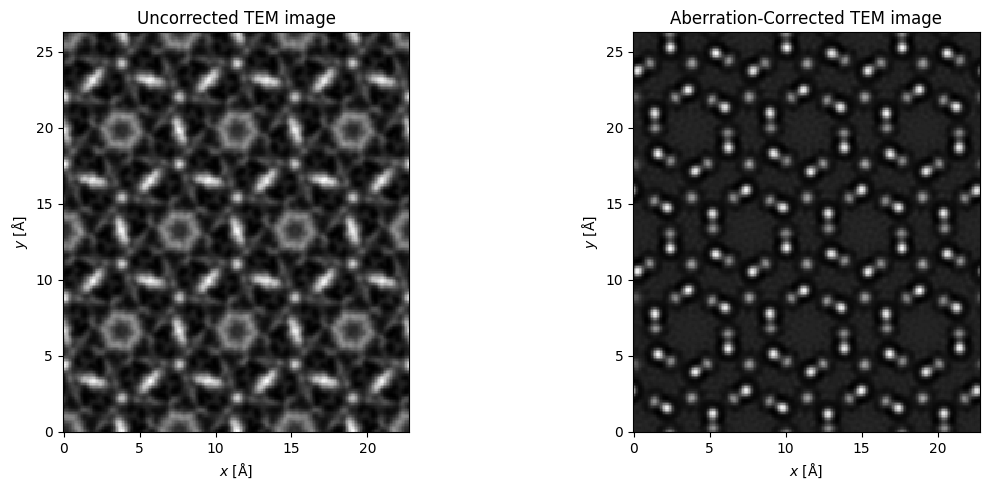

In [32]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/33 [00:00<?, ?it/s]

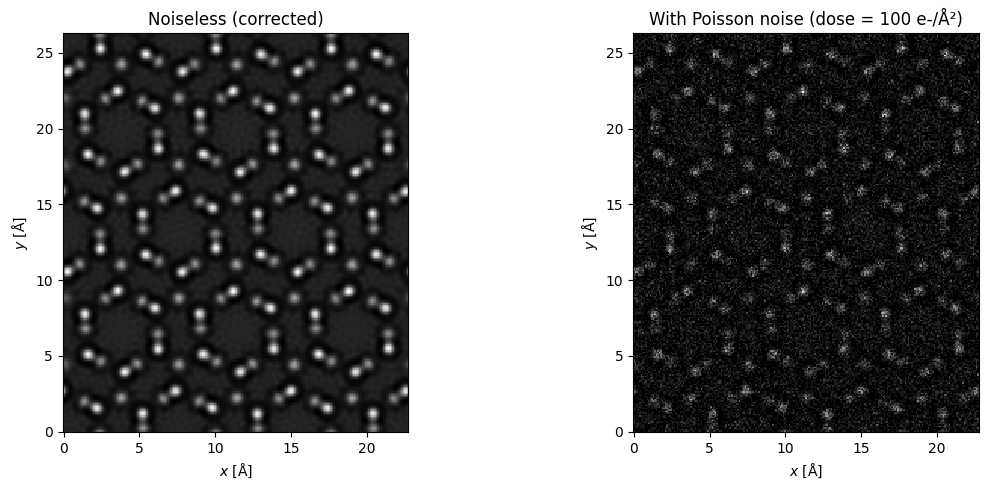

In [33]:
# 必须包含的导入（按作业要求写）
try:
    from abtem.noise import poisson_noise
except:
    poisson_noise = None

# TASK 4: Apply Poisson noise to the aberration-corrected image
dose = 100  # e-/Å²

# TODO: First get the noiseless mean intensity image, then add noise
noiseless_image = image_corrected.intensity().mean(0)

if poisson_noise is not None:
    noisy_image = poisson_noise(noiseless_image, dose)
else:
    noisy_image = noiseless_image.poisson_noise(dose)

# TODO: Plot the noiseless vs noisy images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap="gray", ax=axes[0])
axes[0].set_title("Noiseless (corrected)")

noisy_image.show(cmap="gray", ax=axes[1])
axes[1].set_title(f"With Poisson noise (dose = {dose} e-/Å²)")

plt.tight_layout()
plt.show()

**Comment (Task 4):**

Adding Poisson noise clearly lowers the signal-to-noise ratio of the image. Compared with the noiseless result, the noisy image shows much stronger background fluctuations and looks more grainy overall. The atomic columns are still visible, but their contrast is reduced and the features appear less sharp. This shows that at a limited electron dose, fine structural details become harder to interpret in HRTEM images.

---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**
*The uncorrected CTF has a narrower spatial-frequency transfer range, with multiple zero crossings appearing at relatively low spatial frequencies and faster decay of high-frequency information. As seen in our simulation, the uncorrected image shows weaker contrast and appears more blurred overall. In contrast, the aberration-corrected CTF maintains effective transfer over a wider spatial-frequency range, preserves more high-frequency information, and shows fewer zero crossings, resulting in more stable information transfer.

We observe sharper atomic columns in the aberration-corrected image because high spatial-frequency components correspond to atomic-scale details. In our results, the corrected image shows clearer and more sharply defined atomic columns, while the uncorrected image appears more blurred. This indicates that aberration correction reduces blurring caused by lens aberrations and improves the conversion of high-frequency information into visible contrast.*

**2. Defocus and Contrast:**
*In a conventional (uncorrected) TEM, imaging at exactly zero defocus (Δf = 0) is usually avoided because the CTF is close to zero at low spatial frequencies and cannot effectively transfer phase information, resulting in low image contrast. In our simulation, we also see that structural details are harder to resolve under conditions close to zero defocus. Therefore, a finite defocus is typically used in practice to enhance contrast.

The significance of the Scherzer defocus is that it provides near-optimal imaging contrast in conventional TEM. At this defocus, the CTF transfers information over a wider spatial-frequency range and minimizes zero crossings, allowing high-frequency details to be more effectively converted into visible contrast. As seen in our results, under suitable defocus conditions the atomic columns appear clearer and sharper, highlighting the practical importance of the Scherzer defocus in HRTEM imaging.*

**3. Simulation vs. Reality:**
*Adding Poisson noise reduces the interpretability of the image. In our results, the noisy image shows stronger background fluctuations and a grainier appearance compared with the noiseless image, leading to lower contrast and loss of fine details. Although the atomic columns remain visible, their boundaries become less sharp and weaker features are harder to distinguish, showing how limited electron dose affects reliable interpretation.

In real HRTEM experiments, several additional factors not included in this simulation can further degrade image quality, such as specimen drift, mechanical vibrations, beam instability, incomplete aberration correction, thickness variations, contamination, and detector noise. These effects reduce resolution and contrast, making atomic-scale features more difficult to resolve.*

**4. Multislice Algorithm:**
*For a ~5 nm thick specimen, electrons undergo significant multiple scattering during propagation, so a single projected potential (kinematic approximation) cannot accurately describe the imaging process. In our simulation, the electron wave propagates through the specimen slice by slice and is scattered repeatedly, and these accumulated phase changes affect the final image contrast. The multislice method accounts for this by dividing the specimen into thin slices and sequentially calculating propagation and scattering, providing a more realistic description of dynamical scattering in a specimen of this thickness.*